# Random Forest Model - Ensemble Learning

**Purpose:** Apply Random Forest regressie) for electricity demand forecasting.

**Model Type:** Random Forrse)
- Ensemble of decision trees
- Bootstrap aggregating (bagging)
- Reduces overfitting through averaging
- Handles non-linear relationships n tabular data

**Expected Performance:** RMSE ~250-350 MW
- Should outperform Linear Regression and SVR
- May be competitive with Neural Network
- Much faster training than Neural Network

**Dataset:** Same master dataset (31 features, 108,888 records)

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import time
import warnings
warnings.filterwarnings('ignore')

# Set random seed
np.random.seed(42)

# Plot settings
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

print("Loading master dataset...")
df = pd.read_csv("../../../02_Datasets/processed/master_dataset_complete.csv",
                 parse_dates=['DateTime', 'Date'])

# Feature preparation
exclude_cols = ['DateTime', 'Date', 'Holiday_Name']
feature_cols = [col for col in df.columns if col not in exclude_cols + ['Ontario Demand', 'Market Demand']]
target_col = 'Ontario Demand'

print(f"✓ Data loaded: {df.shape}")
print(f"Features: {len(feature_cols)}")

Loading master dataset...
✓ Data loaded: (109056, 36)
Features: 31


In [2]:
print("Preparing data...")

# Create X and y
X = df[feature_cols].copy()
y = df[target_col].copy()

# Drop rows with missing lag features
mask_valid = df['Demand_Lag_168h'].notna()
X = X[mask_valid]
y = y[mask_valid]

# Fill remaining missing values
X = X.fillna(method='ffill').fillna(method='bfill')

print(f"✓ Data prepared: {X.shape}")

# Split data (same as previous models)
n = len(X)
train_size = int(0.77 * n)
val_size = int(0.08 * n)

X_train = X.iloc[:train_size]
y_train = y.iloc[:train_size]
X_val = X.iloc[train_size:train_size+val_size]
y_val = y.iloc[train_size:train_size+val_size]
X_test = X.iloc[train_size+val_size:]
y_test = y.iloc[train_size+val_size:]

print(f"\nData split:")
print(f"  Train: {len(X_train):,} samples")
print(f"  Val:   {len(X_val):,} samples")
print(f"  Test:  {len(X_test):,} samples")

print(f"\nNote: Random Forest does NOT require feature scaling")

Preparing data...
✓ Data prepared: (108888, 31)

Data split:
  Train: 83,843 samples
  Val:   8,711 samples
  Test:  16,334 samples

Note: Random Forest does NOT require feature scaling


In [3]:
print("Training Random Forest model...")
print("Configuration: 100 trees, max_depth=20, parallel processing")
print("="*70)

start_time = time.time()

# Initialize Random Forest
model = RandomForestRegressor(
    n_estimators=100,      # Number of trees
    max_depth=20,          # Max tree depth (prevents overfitting)
    min_samples_split=5,   # Min samples to split node
    min_samples_leaf=2,    # Min samples in leaf
    max_features='sqrt',   # Features per split
    n_jobs=-1,             # Use all CPU cores
    random_state=42,
    verbose=0
)

# Train model
model.fit(X_train, y_train)

train_time = time.time() - start_time

print(f"✓ Model trained in {train_time:.2f} seconds")
print(f"  Number of trees: {model.n_estimators}")
print(f"  Max depth: {model.max_depth}")

# Make predictions
print("\nMaking predictions...")
y_train_pred = model.predict(X_train)
y_val_pred = model.predict(X_val)
y_test_pred = model.predict(X_test)

# Calculate metrics
def calculate_metrics(y_true, y_pred, set_name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    
    print(f"\n{set_name}:")
    print(f"  RMSE: {rmse:,.2f} MW")
    print(f"  MAE:  {mae:,.2f} MW")
    print(f"  R²:   {r2:.4f}")
    print(f"  MAPE: {mape:.2f}%")
    
    return {'RMSE': rmse, 'MAE': mae, 'R2': r2, 'MAPE': mape}

train_metrics = calculate_metrics(y_train, y_train_pred, "Training Set")
val_metrics = calculate_metrics(y_val, y_val_pred, "Validation Set")
test_metrics = calculate_metrics(y_test, y_test_pred, "Test Set")

print("\n" + "="*70)
print("RANDOM FOREST RESULTS:")
print(f"  Test RMSE: {test_metrics['RMSE']:,.2f} MW")
print(f"  Test R²:   {test_metrics['R2']:.4f}")
print(f"  Training Time: {train_time:.2f} seconds")
print("="*70)

Training Random Forest model...
Configuration: 100 trees, max_depth=20, parallel processing
✓ Model trained in 6.92 seconds
  Number of trees: 100
  Max depth: 20

Making predictions...

Training Set:
  RMSE: 111.55 MW
  MAE:  83.21 MW
  R²:   0.9978
  MAPE: 0.54%

Validation Set:
  RMSE: 239.19 MW
  MAE:  182.52 MW
  R²:   0.9876
  MAPE: 1.15%

Test Set:
  RMSE: 321.30 MW
  MAE:  237.60 MW
  R²:   0.9821
  MAPE: 1.43%

RANDOM FOREST RESULTS:
  Test RMSE: 321.30 MW
  Test R²:   0.9821
  Training Time: 6.92 seconds


In [4]:
# Save results
results_summary = {
    'Model': 'Random Forest',
    'Train_RMSE': train_metrics['RMSE'],
    'Train_R2': train_metrics['R2'],
    'Val_RMSE': val_metrics['RMSE'],
    'Val_R2': val_metrics['R2'],
    'Test_RMSE': test_metrics['RMSE'],
    'Test_R2': test_metrics['R2'],
    'Test_MAE': test_metrics['MAE'],
    'Test_MAPE': test_metrics['MAPE'],
    'Training_Time_Seconds': train_time
}

results_df = pd.DataFrame([results_summary])
comparison_file = '../../../04_Presentation/model_results/06_comparison/model_comparison.csv'
existing_results = pd.read_csv(comparison_file)
updated_results = pd.concat([existing_results, results_df], ignore_index=True)
updated_results.to_csv(comparison_file, index=False)

print("✓ Random Forest results saved!")

✓ Random Forest results saved!


Creating Random Forest visualizations...


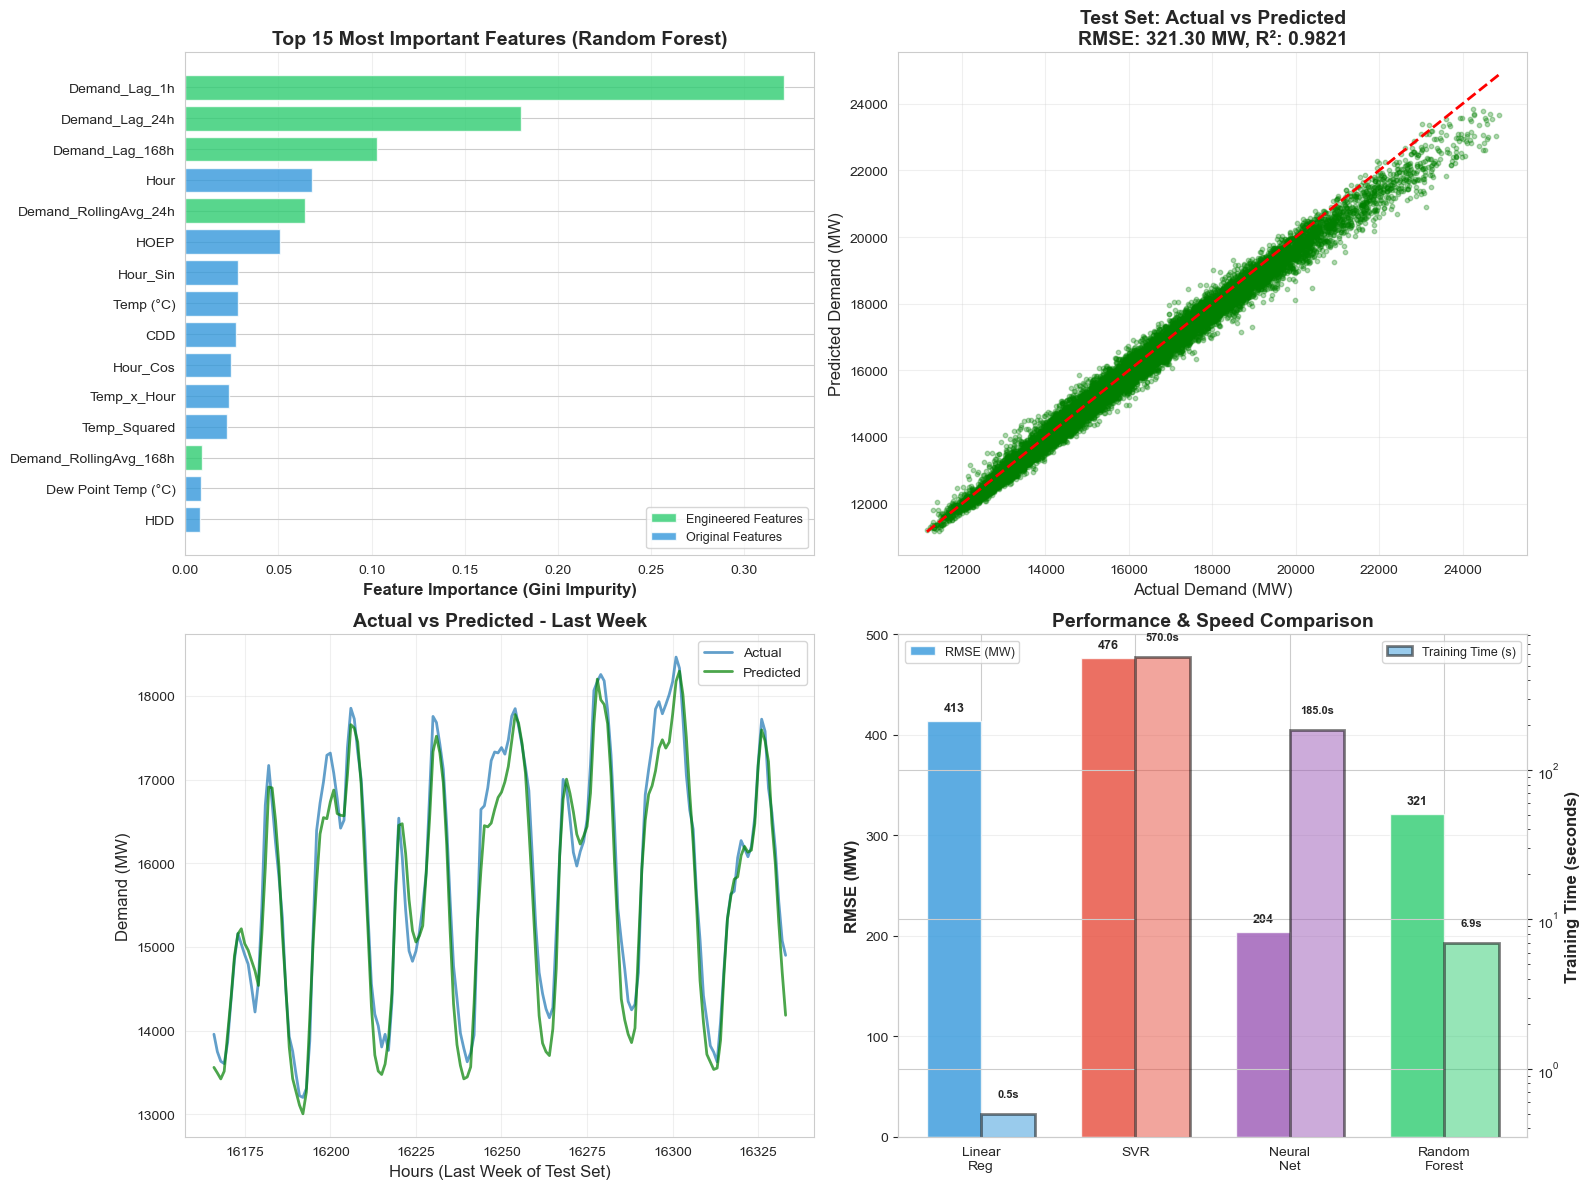


✓ Random Forest visualizations created and saved!

Top 5 Most Important Features:
  14. Demand_Lag_1h: 0.3215
  15. Demand_Lag_24h: 0.1803
  16. Demand_Lag_168h: 0.1030
  1. Hour: 0.0680
  17. Demand_RollingAvg_24h: 0.0644


In [5]:
print("Creating Random Forest visualizations...")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Feature Importance (built-in from Random Forest)
ax1 = axes[0, 0]
feature_importance = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False).head(15)

colors = ['#2ecc71' if 'Lag' in f or 'Rolling' in f else '#3498db' for f in feature_importance['Feature']]
bars = ax1.barh(range(len(feature_importance)), feature_importance['Importance'], color=colors, alpha=0.8)
ax1.set_yticks(range(len(feature_importance)))
ax1.set_yticklabels(feature_importance['Feature'], fontsize=10)
ax1.set_xlabel('Feature Importance (Gini Impurity)', fontsize=12, fontweight='bold')
ax1.set_title('Top 15 Most Important Features (Random Forest)', fontsize=14, fontweight='bold')
ax1.invert_yaxis()
ax1.grid(True, alpha=0.3, axis='x')

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2ecc71', alpha=0.8, label='Engineered Features'),
    Patch(facecolor='#3498db', alpha=0.8, label='Original Features')
]
ax1.legend(handles=legend_elements, loc='lower right', fontsize=9)

# 2. Actual vs Predicted
ax2 = axes[0, 1]
ax2.scatter(y_test, y_test_pred, alpha=0.3, s=10, color='green')
ax2.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
ax2.set_xlabel('Actual Demand (MW)', fontsize=12)
ax2.set_ylabel('Predicted Demand (MW)', fontsize=12)
ax2.set_title(f'Test Set: Actual vs Predicted\nRMSE: {test_metrics["RMSE"]:.2f} MW, R²: {test_metrics["R2"]:.4f}', 
              fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)

# 3. Time series comparison (last week)
ax3 = axes[1, 0]
sample_size = 168
sample_indices = range(len(y_test) - sample_size, len(y_test))
ax3.plot(sample_indices, y_test.iloc[-sample_size:].values, label='Actual', linewidth=2, alpha=0.7)
ax3.plot(sample_indices, y_test_pred[-sample_size:], label='Predicted', linewidth=2, alpha=0.7, color='green')
ax3.set_xlabel('Hours (Last Week of Test Set)', fontsize=12)
ax3.set_ylabel('Demand (MW)', fontsize=12)
ax3.set_title('Actual vs Predicted - Last Week', fontsize=14, fontweight='bold')
ax3.legend(fontsize=10)
ax3.grid(True, alpha=0.3)

# 4. Model Comparison Summary
ax4 = axes[1, 1]
models = ['Linear\nReg', 'SVR', 'Neural\nNet', 'Random\nForest']
rmse_values = [413.25, 476.05, 203.92, test_metrics['RMSE']]
train_times = [0.5, 570, 185, train_time]
colors = ['#3498db', '#e74c3c', '#9b59b6', '#2ecc71']

# Dual axis plot
x = np.arange(len(models))
width = 0.35

bars1 = ax4.bar(x - width/2, rmse_values, width, label='RMSE (MW)', color=colors, alpha=0.8)
ax4_twin = ax4.twinx()
bars2 = ax4_twin.bar(x + width/2, train_times, width, label='Training Time (s)', 
                     color=colors, alpha=0.5, edgecolor='black', linewidth=2)

ax4.set_ylabel('RMSE (MW)', fontsize=12, fontweight='bold')
ax4_twin.set_ylabel('Training Time (seconds)', fontsize=12, fontweight='bold')
ax4.set_title('Performance & Speed Comparison', fontsize=14, fontweight='bold')
ax4.set_xticks(x)
ax4.set_xticklabels(models, fontsize=10)
ax4.set_ylim([0, 500])
ax4_twin.set_yscale('log')
ax4.legend(loc='upper left', fontsize=9)
ax4_twin.legend(loc='upper right', fontsize=9)
ax4.grid(True, alpha=0.3, axis='y')

# Add value labels
for i, (rmse, time_val) in enumerate(zip(rmse_values, train_times)):
    ax4.text(i - width/2, rmse + 10, f'{rmse:.0f}', ha='center', fontsize=9, fontweight='bold')
    ax4_twin.text(i + width/2, time_val * 1.3, f'{time_val:.1f}s', ha='center', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.savefig('../../../04_Presentation/model_results/04_random_forest/performance.png', 
            dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Random Forest visualizations created and saved!")
print(f"\nTop 5 Most Important Features:")
for i, row in feature_importance.head(5).iterrows():
    print(f"  {i+1}. {row['Feature']}: {row['Importance']:.4f}")